In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv('Pharma_Industry (1).csv')
df

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1
...,...,...,...,...,...,...
495,-1.553759,0.506938,0.817890,-0.661245,-1.345393,0
496,0.551476,1.714321,0.340589,1.712558,-0.496315,1
497,-1.072743,-0.221137,0.239247,1.112924,-0.285838,1
498,1.661259,0.245759,-0.457096,0.633355,0.657413,0


In [3]:
df.shape

(500, 6)

In [4]:
df.size

3000

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [6]:
df.isnull().sum()

Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

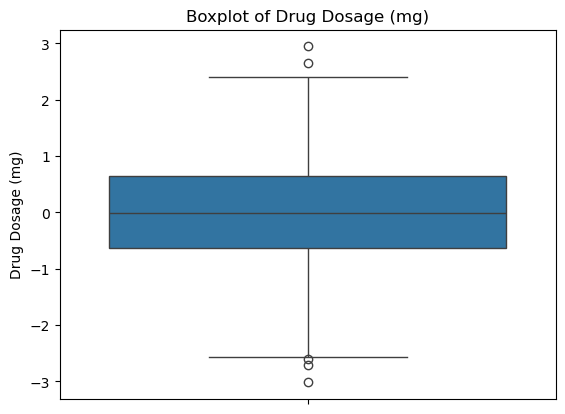

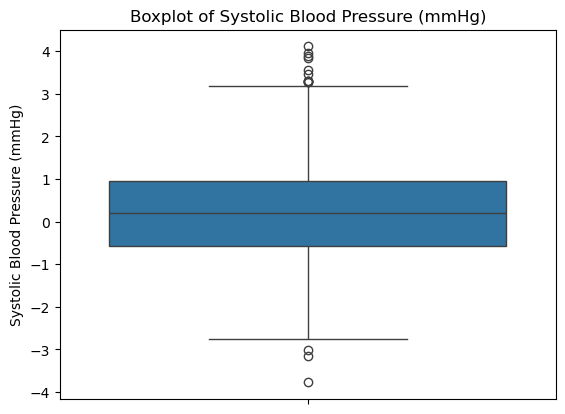

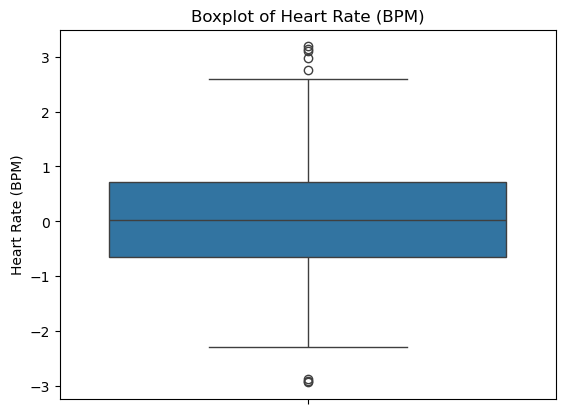

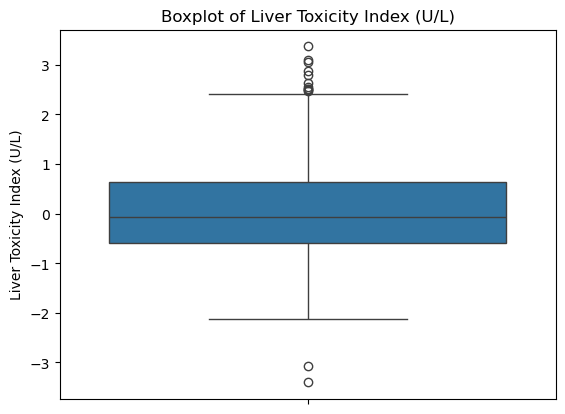

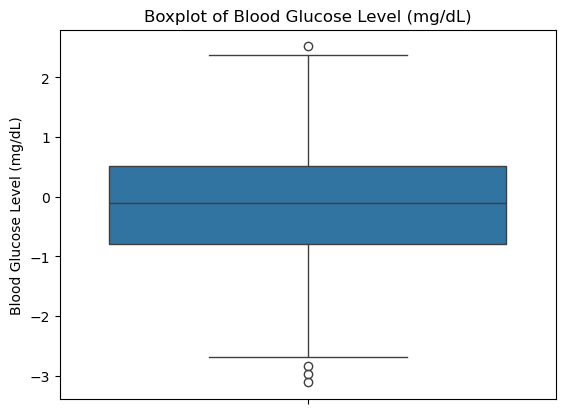

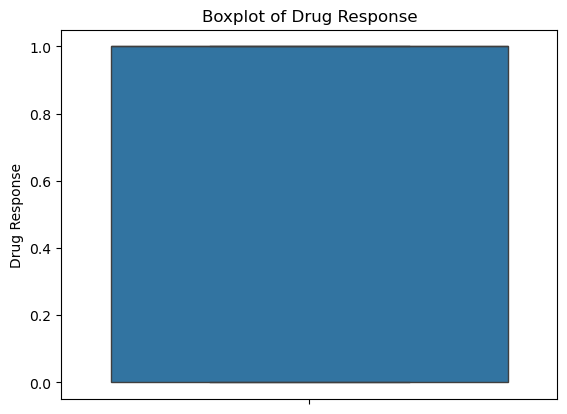

In [8]:
for col in df.select_dtypes(include=['int','float']).columns:
    sns.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [9]:
for i in df.select_dtypes(include=['int','float']).columns:
    q1=df[i].quantile(0.25)
    q3=df[i].quantile(0.75)
    iqr=q3-q1
    lower=q1-1.5*iqr
    upper=q3+1.5*iqr
    df[i]=df[i].clip(lower,upper)

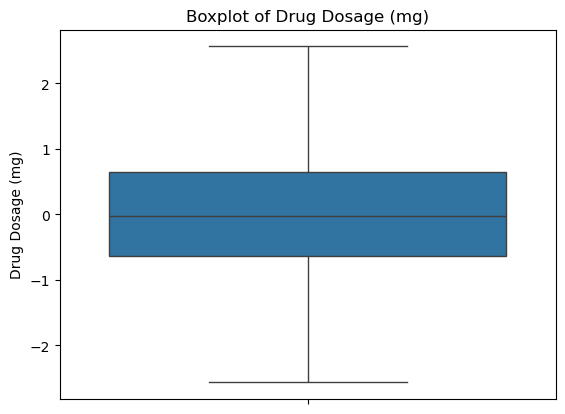

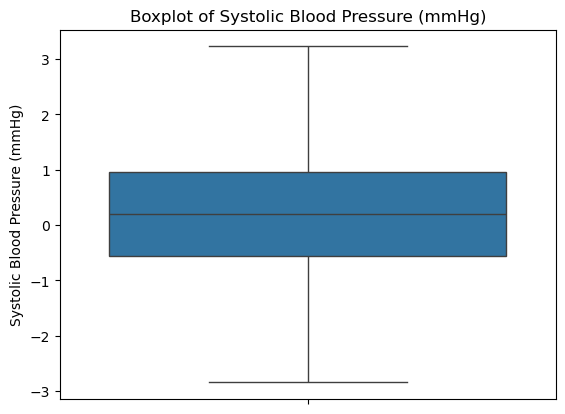

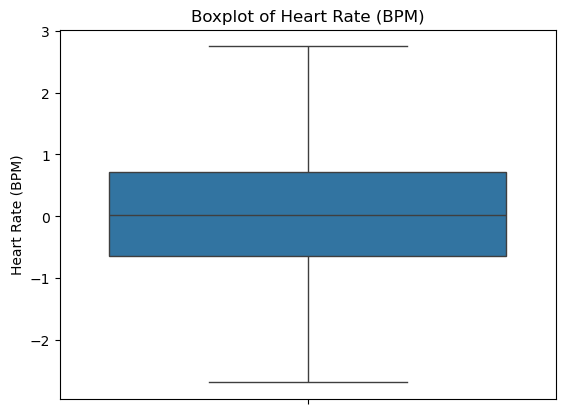

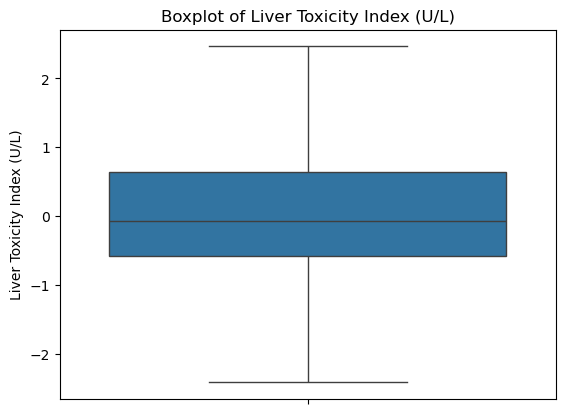

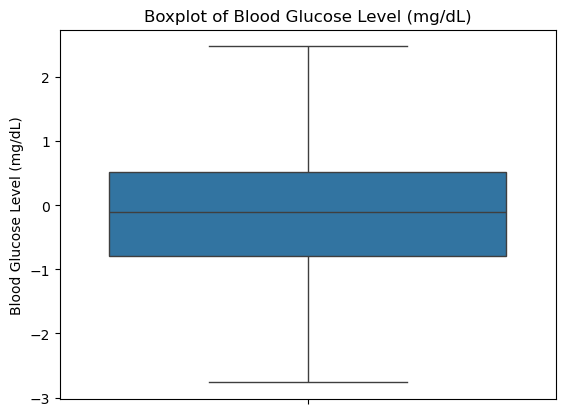

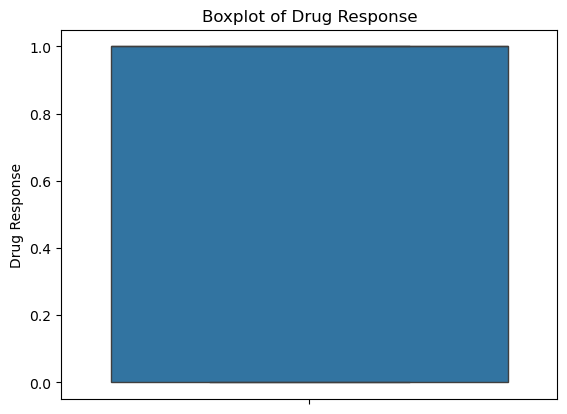

In [10]:
for col in df.select_dtypes(include=['int','float']).columns:
    sns.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

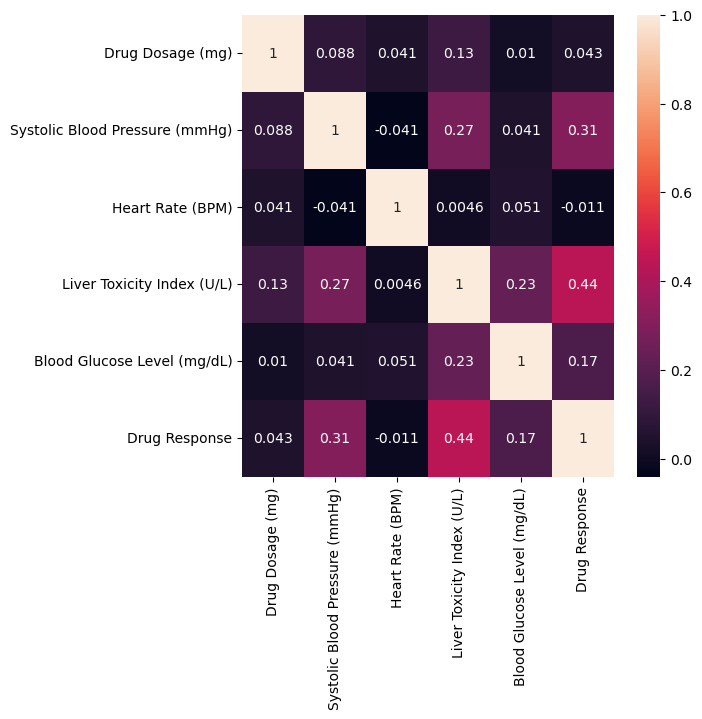

In [11]:
plt.figure(figsize=(6,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [13]:
x=df.drop(columns=['Drug Response'])
y=df['Drug Response']

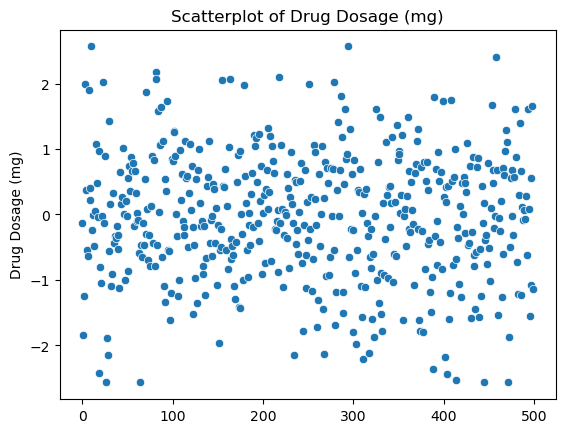

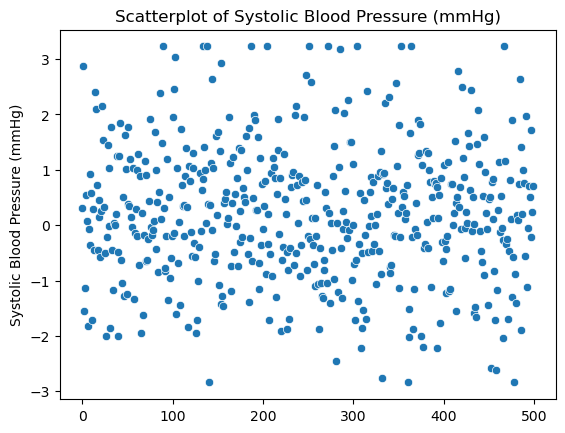

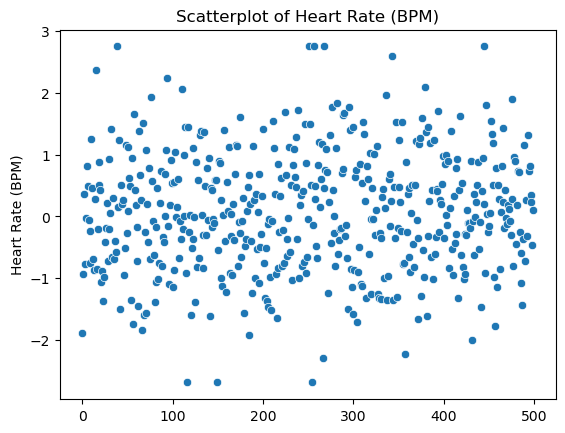

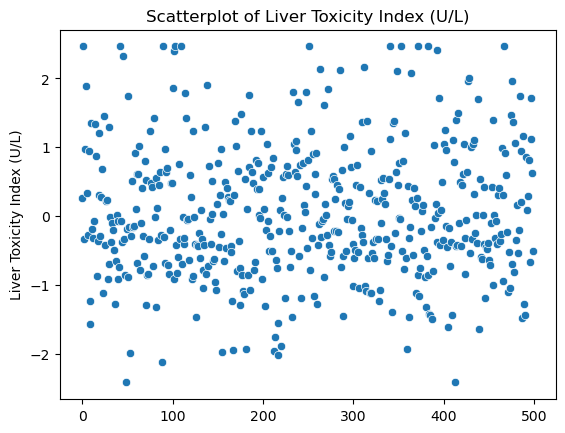

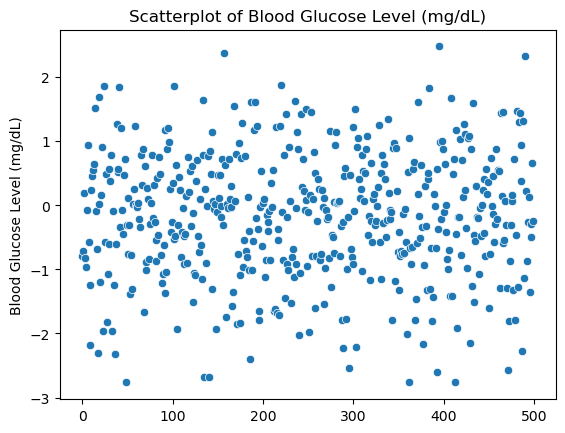

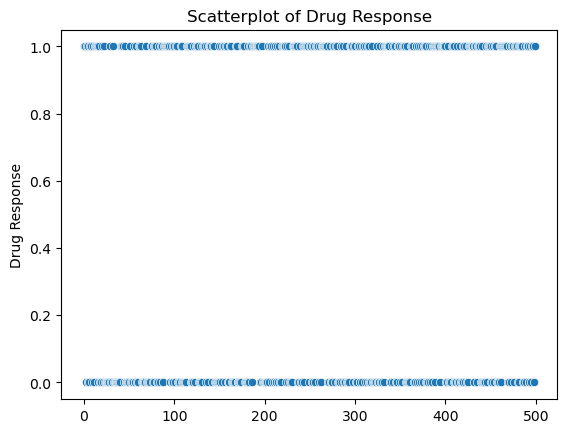

In [14]:
for col in df.select_dtypes(include=['int','float']).columns:
    sns.scatterplot(df[col])
    plt.title(f"Scatterplot of {col}")
    plt.show()

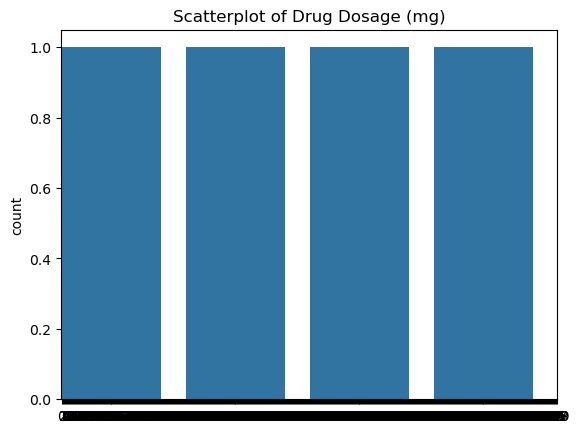

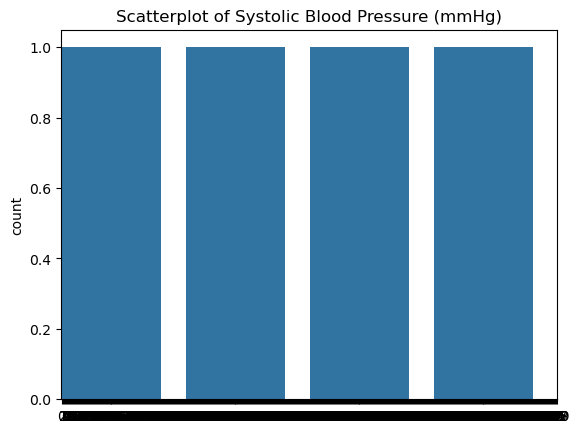

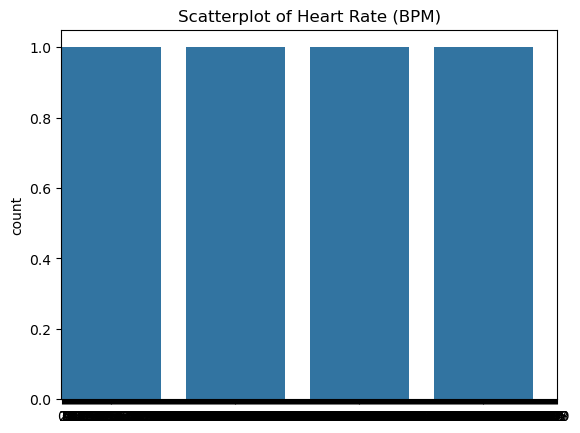

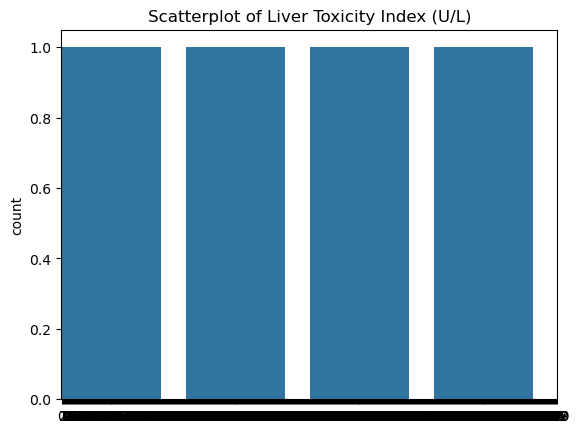

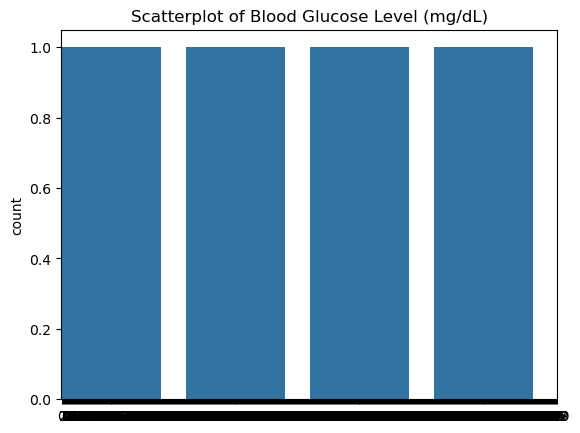

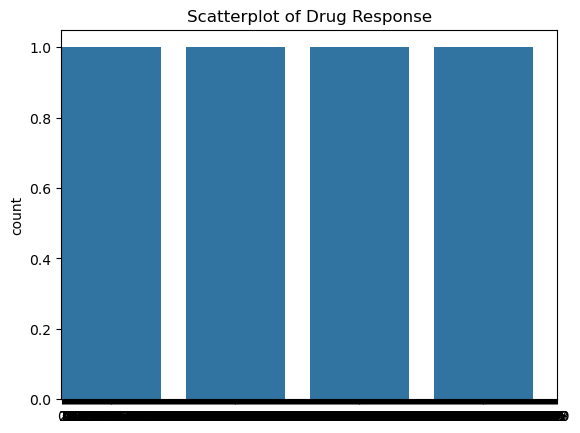

In [15]:
for col in df.select_dtypes(include=['int','float']).columns:
    sns.countplot(df[col])
    plt.title(f"Scatterplot of {col}")
    plt.show()

In [16]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=50)

In [18]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
svc=SVC()
svc.fit(x_train,y_train)
pred_train=svc.predict(x_train)
pred_test=svc.predict(x_test)
print("Train Acc is:",accuracy_score(y_train,pred_train))
print("Test Acc is:",accuracy_score(y_test,pred_test))

Train Acc is: 0.795
Test Acc is: 0.8


In [19]:
pred_train

array([0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1,
       1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1,
       0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,

In [20]:
pred_test

array([1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1])

In [21]:
from sklearn.metrics import *
print("Accuracy is:",accuracy_score(y_test,pred_test))
print("Precision is:",precision_score(y_test,pred_test))
print("Recall score is:",recall_score(y_test,pred_test))
print("F1 score is:",f1_score(y_test,pred_test))

Accuracy is: 0.8
Precision is: 0.851063829787234
Recall score is: 0.7547169811320755
F1 score is: 0.8


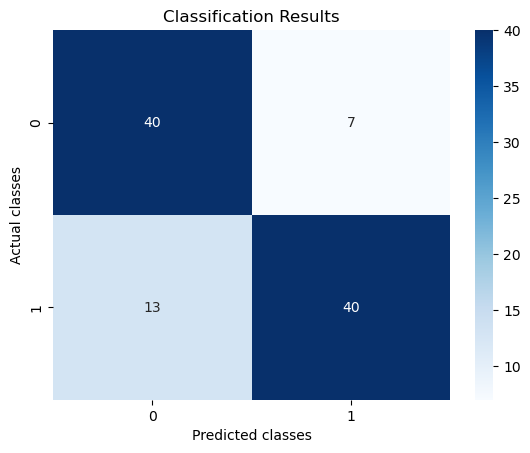

In [28]:
cm=confusion_matrix(y_test,pred_test)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted classes")
plt.ylabel("Actual classes")
plt.title("Classification Results")
plt.show()

In [30]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
svc=SVC(kernel='linear')
svc.fit(x_train,y_train)
pred_train=svc.predict(x_train)
pred_test=svc.predict(x_test)
print("Train Acc is:",accuracy_score(y_train,pred_train))
print("Test Acc is:",accuracy_score(y_test,pred_test))

Train Acc is: 0.705
Test Acc is: 0.77


In [32]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
svc=SVC(kernel='poly')
svc.fit(x_train,y_train)
pred_train=svc.predict(x_train)
pred_test=svc.predict(x_test)
print("Train Acc is:",accuracy_score(y_train,pred_train))
print("Test Acc is:",accuracy_score(y_test,pred_test))

Train Acc is: 0.7475
Test Acc is: 0.75


In [34]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
svc=SVC(kernel='sigmoid')
svc.fit(x_train,y_train)
pred_train=svc.predict(x_train)
pred_test=svc.predict(x_test)
print("Train Acc is:",accuracy_score(y_train,pred_train))
print("Test Acc is:",accuracy_score(y_test,pred_test))

Train Acc is: 0.6275
Test Acc is: 0.63


Comparision:
Linear kernel gives the best test accuracy (77%), so it performs best on unseen data.
Polynomial kernel has the highest training accuracy (74.75%) but slightly lower test accuracy (75%).
Sigmoid kernel performs the worst, with only 63% test accuracy.
Therefore, Linear SVM is the best kernel for this dataset based on test accuracy.

Strengths and Weaknesses:
1. The dataset was explored using basic EDA techniques such as distributions, box plots,
  and correlations.
2. Data preprocessing was performed to prepare the features for SVM classification.
3. The dataset was divided into training and testing sets.
4. SVM models with different kernels were implemented and compared.
5. The linear kernel achieved 70.5% training and 77% testing accuracy.
6. The polynomial kernel achieved 74.75% training and 75% testing accuracy.
7. The sigmoid kernel performed lowest, with 62.75% training and 63% testing accuracy.
8. The results show that the linear kernel is the best-performing model for this dataset.

 Overall, SVM provided reasonable classification performance, although further preprocessing and tuning could improve the results.

Practical Implications of SVM:
1. Healthcare: SVM can classify diseases and predict drug responses from patient data.
2. Finance: It can detect fraudulent transactions and classify financial risks.
3. Text Classification: SVM is effective for spam detection, sentiment analysis, and document classification.
4. Image Recognition: It can classify images based on patterns, shapes, and features.
5. Overall: SVM provides accurate classification and works well with high-dimensional data, but requires proper preprocessing and kernel selection.

I've viewed the drug response document also and i understand the  importance of classification of data and predicting the data through ML algorithms to view their effects and responses on the patients and implementing medicine and controlling dosages according to the results,
So,we can say it should be precise and without any errors and data should be consistent to make judgements.
As it is a critical decision to be made by the healthcare departments the data should be accurate.